In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score ## 評估指標函式庫
from sklearn.model_selection import train_test_split

In [2]:
# --- 工具函數定義 ---
# 固定亂數種子以確保每次執行結果一致 
np.random.seed(seed=67) 

# sigmoid 函式
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# sigmoid 導數函式
def sigmoid_derivative(z):
    # 公式: f'(n) = σ(n)(1 - σ(n))
    s = sigmoid(z)
    return s * (1 - s)

def xavier_init(n_in, n_out):
    limit = np.sqrt(6 / (n_in + n_out))
    return np.random.uniform(-limit, limit, (n_in, n_out))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def he_init(n_in, n_out):
    limit = np.sqrt(6 / n_in)
    return np.random.uniform(-limit, limit, (n_in, n_out))

def random_init(n_in, n_out, scale=0.01):
    return np.random.uniform(-scale, scale, (n_in, n_out))

# softmax 函式
def softmax(z):
    # 找出 z 中每一列的最大值 c 並維持原本的維度
    c = np.max(z, axis=1, keepdims=True) 
    
    # 數值穩定化
    exp_z = np.exp(z - c)
    
    # 找出每一列的總和並維持原本的維度
    total_exp_z = np.sum(exp_z, axis=1, keepdims=True) 
    
    # 計算並維持原本的維度
    a = exp_z / total_exp_z
    return a

# 交叉熵損失函式
def cross_entropy_loss(a, y):
    loss = -np.sum(y * np.log(a)) / a.shape[0]
    return loss

# 計算準確率函式
def calculate_accuracy(a, y):
    # 列出每一列模型輸出機率的最大值位置 --> 預測標籤
    predicted_labels = np.argmax(a, axis=1)
    
    # 列出原數據每一列的最大值的位置 --> 真實標籤 
    true_labels = np.argmax(y, axis=1)
    
    # 逐一比較預測標籤和真實標籤是否相等
    # 然後計算布林陣列中 "True" 的平均值，即為準確率
    accuracy = np.mean(predicted_labels == true_labels)
    return accuracy

def forward_pass(X, w1, b1, w2, b2):
    z1 = X @ w1 + b1
    
    h1 = relu(z1)
        
    z2 = h1 @ w2 + b2
    return softmax(z2)

def encode_labels_binary(df):
    labels = np.zeros((df.shape[0], 2)) 
    for i in range(df.shape[0]):
        val = df.iloc[i]['DIQ010']
        if val == 1.0 or val == 3.0: 
            labels[i] = [0, 1]  # Index 1: 有風險 (確診 + 邊緣)
        elif val == 2.0: 
            labels[i] = [1, 0]  # Index 0: 無糖尿病 (健康)
    return labels

====================== Group1 ======================

Final Test Accuracy): 82.56%

--- 混淆矩陣 (Confusion Matrix) ---

[[92 18]
 [16 69]]

--- 分類評估報告 (Classification Report) ---

              precision    recall  f1-score   support

  Health (0)       0.85      0.84      0.84       110
    Risk (1)       0.79      0.81      0.80        85

    accuracy                           0.83       195
   macro avg       0.82      0.82      0.82       195
weighted avg       0.83      0.83      0.83       195

====================== Group2 ======================

Final Test Accuracy): 84.72%

--- 混淆矩陣 (Confusion Matrix) ---

[[62 10]
 [12 60]]

--- 分類評估報告 (Classification Report) ---

              precision    recall  f1-score   support

  Health (0)       0.84      0.86      0.85        72
    Risk (1)       0.86      0.83      0.85        72

    accuracy                           0.85       144
   macro avg       0.85      0.85      0.85       144
weighted avg       0.85      0.85      0.85    

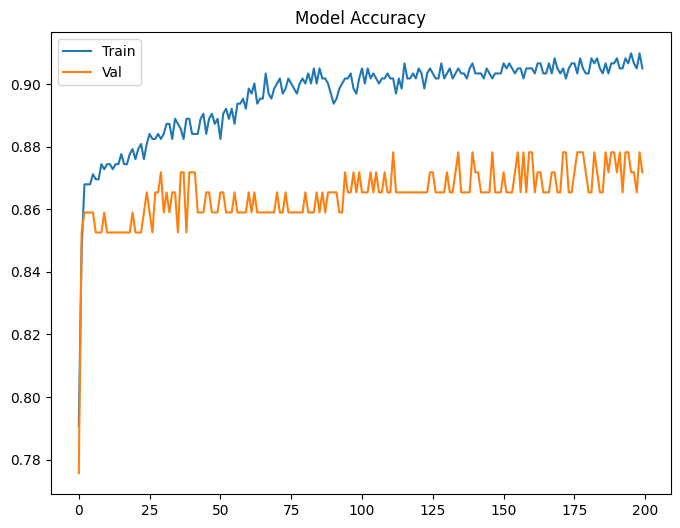

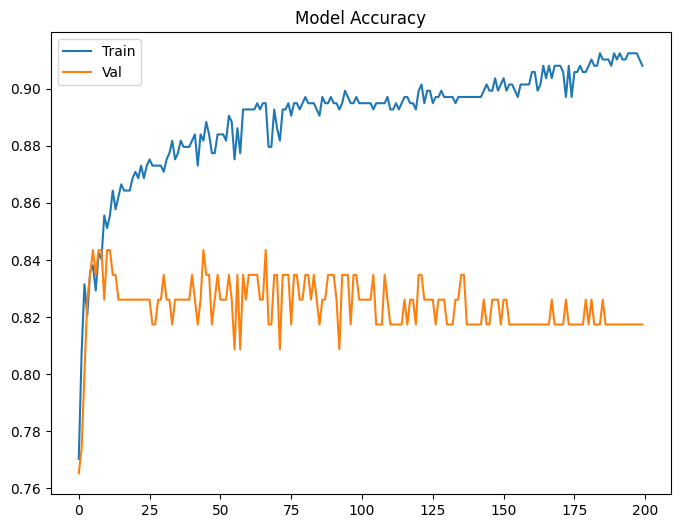

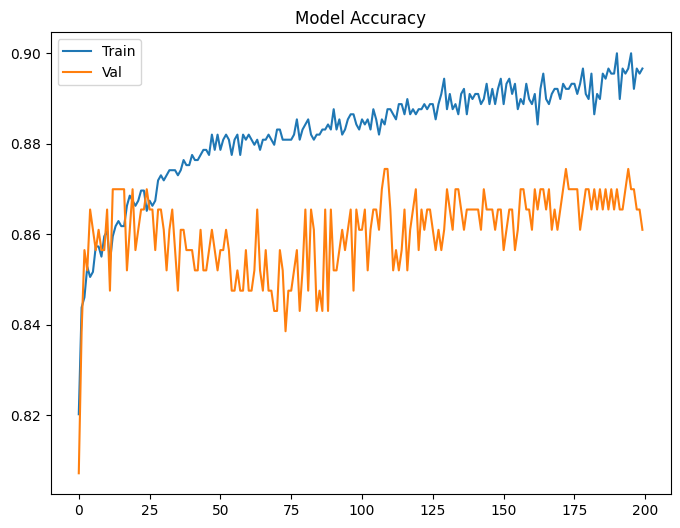

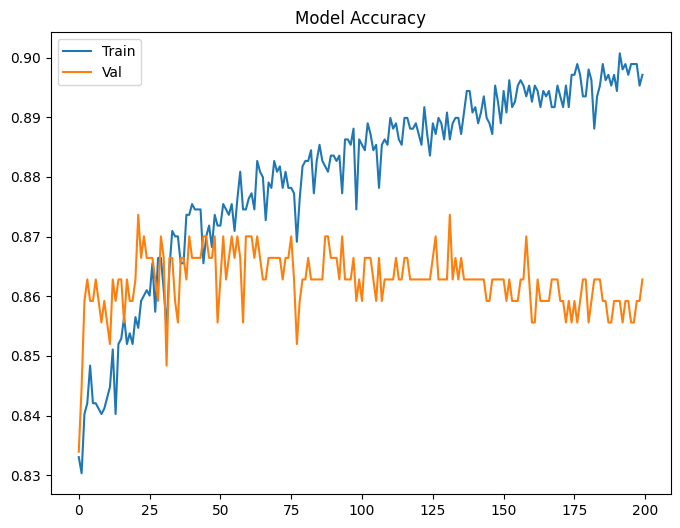

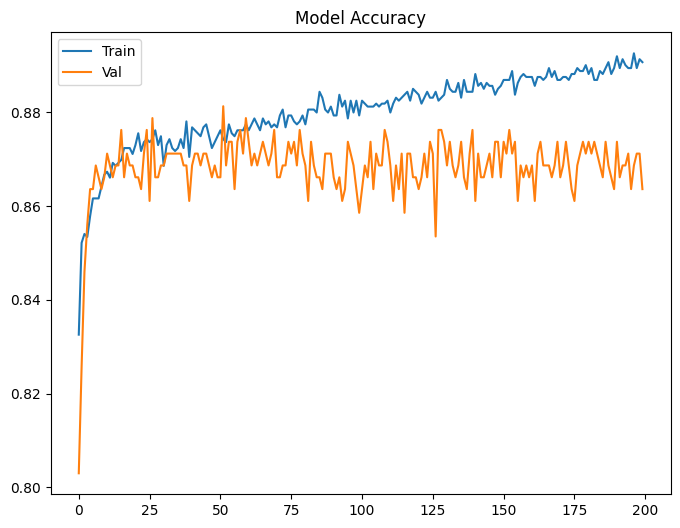

In [10]:
group = ["Group1", "Group2", "Group3", "Group4", "Group5"]

for group_name in group:

    data = pd.read_csv(f'./data_set/balance_data/balance_data_{group_name}.csv')
    
    # 取得全部資料的標籤 Y
    Y_all = encode_labels_binary(data)

    # 移除不具特徵意義的序列號與標籤欄位，分離出特徵 X
    X_all_raw = data.drop(columns=['SEQN', 'DIQ010'])

    # 3. 切分資料集 (使用 train_test_split)
    # 第一步：切分出 80% 作為訓練+驗證，20% 作為最終測試
    X_temp_raw, X_test_raw, Y_temp, Y_test = train_test_split(
        X_all_raw, Y_all, test_size=0.2, random_state=42
    )

    # 第二步：從剩下的 80% 中，再切分出 80% 訓練、20% 驗證
    X_train_raw, X_val_raw, Y_train, Y_val = train_test_split(
        X_temp_raw, Y_temp, test_size=0.2, random_state=42
    )

    # 4. 執行標準化： fit 僅用於訓練集
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val = scaler.transform(X_val_raw)  # 驗證集僅 transform
    X_test = scaler.transform(X_test_raw) # 測試集僅 transform

    # --- 參數初始化 ---
    input_Neurons = X_train.shape[1]
    hidden_Neurons = 512 
    output_Neurons = 2 

    w1 = he_init(input_Neurons, hidden_Neurons)
    w2 = he_init(hidden_Neurons, output_Neurons)
    b1 = np.zeros((1, hidden_Neurons))
    b2 = np.zeros((1, output_Neurons))

    lr = 0.005
    epochs = 200
    batch_size = 32
    n_batches = int(X_train.shape[0] / batch_size)

    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []
    best_val_accuracy = 0.0
    best_params = {}

    # --- 訓練流程 ---
    for epoch in range(epochs):
        perm = np.random.permutation(X_train.shape[0])
        X_shuffled, Y_shuffled = X_train[perm], Y_train[perm]
        
        for i in range(n_batches):
            start = i * batch_size
            end = start + batch_size
            X_batch, Y_batch = X_shuffled[start:end], Y_shuffled[start:end]
            curr_bs = X_batch.shape[0]

            # 順向傳播
            n1 = X_batch @ w1 + b1
            a1 = relu(n1)
            n2 = a1 @ w2 + b2
            a2 = softmax(n2)
            
            # 反向傳播
            grad2 = a2 - Y_batch
            grad_w2 = a1.T @ grad2 / curr_bs
            grad_b2 = np.sum(grad2, axis=0, keepdims=True) / curr_bs
            
            d_act = relu_derivative(n1)
            grad1 = (grad2 @ w2.T) * d_act
            grad_w1 = X_batch.T @ grad1 / curr_bs
            grad_b1 = np.sum(grad1, axis=0, keepdims=True) / curr_bs
            
            # 更新權重
            w1 -= lr * grad_w1
            b1 -= lr * grad_b1
            w2 -= lr * grad_w2
            b2 -= lr * grad_b2
        
        # 評估
        a_train = forward_pass(X_train, w1, b1, w2, b2)
        a_val = forward_pass(X_val, w1, b1, w2, b2)
        
        t_loss, v_loss = cross_entropy_loss(a_train, Y_train), cross_entropy_loss(a_val, Y_val)
        t_acc, v_acc = calculate_accuracy(a_train, Y_train), calculate_accuracy(a_val, Y_val)
        
        train_loss_history.append(t_loss)
        val_loss_history.append(v_loss)
        train_acc_history.append(t_acc)
        val_acc_history.append(v_acc)
        
        if v_acc > best_val_accuracy:
            best_val_accuracy = v_acc
            best_params = {"w1": w1.copy(), "b1": b1.copy(), "w2": w2.copy(), "b2": b2.copy()}

    # --- 測試集最終評估 ---
    a_test = forward_pass(X_test, best_params["w1"], best_params["b1"], best_params["w2"], best_params["b2"])

    # 取得預測的索引 (0 或 1)
    predicted_indices = np.argmax(a_test, axis=1)
    true_indices = np.argmax(Y_test, axis=1)


    print(f"====================== {group_name} ======================")

    # 計算整體準確率
    test_acc = accuracy_score(true_indices, predicted_indices)
    print(f"\nFinal Test Accuracy): {test_acc*100:.2f}%")

    target_names = ['Health (0)', 'Risk (1)']

    print()

    # 顯示並繪製混淆矩陣
    print("--- 混淆矩陣 (Confusion Matrix) ---\n")
    cm = confusion_matrix(true_indices, predicted_indices)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, 
                yticklabels=target_names)
    plt.title('Binary Classification Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    if not os.path.exists("./DL_output"): 
        os.makedirs("./DL_output")
        
    plt.savefig(f"./DL_output/DL_CM_{group_name}.png")
    plt.clf()

    # 顯示分類報告
    # 0 代表健康，1 代表有風險
    print("\n--- 分類評估報告 (Classification Report) ---\n")
    print(classification_report(true_indices, predicted_indices, target_names=target_names, zero_division=0))

    # 儲存視覺化結果
    plt.plot(train_acc_history, label="Train")
    plt.plot(val_acc_history, label="Val")
    plt.title("Model Accuracy")
    plt.legend()
    plt.savefig(f"./DL_output/accuracy_curve_{group_name}.png")